In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
from pathlib import Path
import csv
import cv2
from tqdm import tqdm
import time
import logging


In [2]:
!pip install -U albumentations --user

In [3]:
from pathlib import Path
import json
import random
import re
from collections import Counter

import numpy as np
import cv2
import matplotlib.pyplot as plt

try:
    import albumentations as A
except Exception:
    A = None


ROOT = Path.cwd() / "data_daxuli"  # Default root directory for data; can be overridden in notebooks
TRAIN_MANIFEST = ROOT / "train" / "manifest.json"
VAL_MANIFEST = ROOT / "validation" / "manifest.json"
TEST_MANIFEST = ROOT / "test" / "manifest.json"


# VN-safe preset: keep Vietnamese marks, reduce aggressive deformation
VN_SAFE_CONFIG = {
    "aug": {
        "p_apply": 0.5,
        "shear_range": (-0.2, 0.2),
        "rotation_range": (-1.2, 1.2),
        "elastic_sigma": [2, 3],
        "elastic_alpha": [15, 20],
        "geometric_distort_limit": 0.08,
        "geometric_perspective_scale": (0.02, 0.05),
    },
    "tta": {
        "num_shear": 4,
        "num_rot": 4,
        "shear_range": (-0.2, 0.2),
        "rotation_range": (-1.0, 1.0),
        "lambda": 1.0,
        "omega": 0.25,
    },
    "label": {
        "lowercase": True,
        "remove_punctuation": False,
    },
}

print(f"Albumentations available: {A is not None}")


c:\Users\voquy\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Albumentations available: True


In [4]:
import logging
import time

# Reset lại tất cả các handlers cũ
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

# Cấu hình lại từ đầu
logging.basicConfig(
    filename='training_debug.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='w', # 'w' để ghi đè mới mỗi lần chạy
    force=True    # Ép buộc áp dụng cấu hình này (chỉ có từ Python 3.8+)
)
logger = logging.getLogger(__name__)

In [5]:
def load_manifest(path: Path):
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def flatten_entries(manifest_obj):
    out = []
    for sample in manifest_obj:
        for item in sample.get("images", []):
            out.append(item)
    return out


train_entries = flatten_entries(load_manifest(TRAIN_MANIFEST))
val_entries = flatten_entries(load_manifest(VAL_MANIFEST))
test_entries = flatten_entries(load_manifest(TEST_MANIFEST))

print(f"Train lines: {len(train_entries)}")
print(f"Val lines:   {len(val_entries)}")
print(f"Test lines:  {len(test_entries)}")

# Quick Vietnamese label diagnostics
all_texts = [x["text"] for x in train_entries + val_entries + test_entries]
num_upper = sum(any(ch.isupper() for ch in t) for t in all_texts)
num_punct = sum(bool(re.search(r"[^\w\s]", t, flags=re.UNICODE)) for t in all_texts)

print(f"Lines containing uppercase: {num_upper}/{len(all_texts)}")
print(f"Lines containing punctuation: {num_punct}/{len(all_texts)}")

Train lines: 4993
Val lines:   1181
Test lines:  1055
Lines containing uppercase: 5088/7229
Lines containing punctuation: 6513/7229


In [6]:
def ensure_binary_black_bg(img: np.ndarray) -> np.ndarray:
    # Keep background dark without forcing a hard re-binarization that can thicken strokes.
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    out = np.clip(img, 0, 255).astype(np.uint8)

    # If border becomes bright after a transform, flip polarity back.
    border = np.concatenate([out[0, :], out[-1, :], out[:, 0], out[:, -1]])
    if float(np.mean(border)) > 150.0:
        out = 255 - out

    return out


def shear_image(img: np.ndarray, k: float):
    h, w = img.shape[:2]
    # x' = x + k*y
    M = np.array([[1.0, k, 0.0], [0.0, 1.0, 0.0]], dtype=np.float32)
    new_w = int(w + abs(k) * h)
    if k < 0:
        M[0, 2] = abs(k) * h
    sheared = cv2.warpAffine(
        img,
        M,
        (new_w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )
    # Back to original width for stable training shape
    sheared = cv2.resize(sheared, (w, h), interpolation=cv2.INTER_LINEAR)
    return ensure_binary_black_bg(sheared)


def rotate_image(img: np.ndarray, angle_deg: float):
    h, w = img.shape[:2]
    center = (w / 2.0, h / 2.0)
    M = cv2.getRotationMatrix2D(center, angle_deg, 1.0)
    cos = abs(M[0, 0])
    sin = abs(M[0, 1])
    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))
    M[0, 2] += (new_w / 2.0) - center[0]
    M[1, 2] += (new_h / 2.0) - center[1]
    rotated = cv2.warpAffine(
        img,
        M,
        (new_w, new_h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=0,
    )
    rotated = cv2.resize(rotated, (w, h), interpolation=cv2.INTER_LINEAR)
    return ensure_binary_black_bg(rotated)


def elastic_image(img: np.ndarray, sigma: int, alpha: int):
    if A is None:
        return ensure_binary_black_bg(img)
    aug = A.ElasticTransform(alpha=float(alpha), sigma=float(sigma), p=1.0)
    out = aug(image=img)["image"]
    return ensure_binary_black_bg(out)


def geometric_image(img: np.ndarray):
    if A is None:
        return ensure_binary_black_bg(img)
    # Reduced distortion strength for Vietnamese diacritics safety
    aug = A.OneOf(
        [
            A.OpticalDistortion(distort_limit=VN_SAFE_CONFIG["aug"]["geometric_distort_limit"], p=1.0),
            A.GridDistortion(num_steps=5, distort_limit=VN_SAFE_CONFIG["aug"]["geometric_distort_limit"], p=1.0),
            A.Perspective(scale=VN_SAFE_CONFIG["aug"]["geometric_perspective_scale"], p=1.0),
        ],
        p=1.0,
    )
    out = aug(image=img)["image"]
    return ensure_binary_black_bg(out)


def apply_single_aug_paper(img: np.ndarray, p_apply: float = None):
    if p_apply is None:
        p_apply = VN_SAFE_CONFIG["aug"]["p_apply"]

    if random.random() > p_apply:
        return ensure_binary_black_bg(img), "none"

    op = random.choice(["shear", "rotation", "elastic", "geometric"])

    if op == "shear":
        lo, hi = VN_SAFE_CONFIG["aug"]["shear_range"]
        k = random.uniform(lo, hi)
        return shear_image(img, k), f"shear(k={k:.3f})"

    if op == "rotation":
        lo, hi = VN_SAFE_CONFIG["aug"]["rotation_range"]
        theta = random.uniform(lo, hi)
        return rotate_image(img, theta), f"rotation(theta={theta:.2f})"

    if op == "elastic":
        sigma = random.choice(VN_SAFE_CONFIG["aug"]["elastic_sigma"])
        alpha = random.choice(VN_SAFE_CONFIG["aug"]["elastic_alpha"])
        return elastic_image(img, sigma, alpha), f"elastic(sigma={sigma}, alpha={alpha})"

    return geometric_image(img), "geometric(distort/stretch/perspective)"

In [ ]:
# ==================== MODEL DEFINITION ====================
class CNNBiLSTMCTC(nn.Module):
    def __init__(self, num_classes, input_height=100):
        super(CNNBiLSTMCTC, self).__init__()
        
        self.num_classes = num_classes
        
        # ==================== CNN BLOCK ====================
        # Block 1: 32 filters - học các cạnh
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # H/2
        self.dropout1 = nn.Dropout(0.2)
        
        # Block 2: 64 filters - học các cấu trúc phức tạp hơn như móc, góc
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        
        self.conv5 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn5 = nn.BatchNorm2d(64)
        
        self.conv6 = nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1)
        self.bn6 = nn.BatchNorm2d(64)
        
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)  # H/4
        self.dropout2 = nn.Dropout(0.3)
        
        # Block 3: 128 filters
        self.conv7 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn7 = nn.BatchNorm2d(128)
        
        self.conv8 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn8 = nn.BatchNorm2d(128)
        
        self.conv9 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn9 = nn.BatchNorm2d(128)
        
        self.conv10 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn10 = nn.BatchNorm2d(128)
        
        self.conv11 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn11 = nn.BatchNorm2d(128)
        
        self.conv12 = nn.Conv2d(128, 128, kernel_size=3, stride=1, padding=1)
        self.bn12 = nn.BatchNorm2d(128)
        self.dropout3 = nn.Dropout(0.4)

        # After column-wise pooling in forward(), each time-step has 128 features.
        self.rnn_input_size = 128
        
        
        # ==================== BiLSTM BLOCK ====================
        self.lstm1 = nn.LSTM(
            input_size=self.rnn_input_size,
            hidden_size=256,
            num_layers=1,
            bidirectional=True,
            batch_first=False
        )
        
        self.lstm2 = nn.LSTM(
            input_size=512,  # 256 * 2 (bidirectional)
            hidden_size=256,
            num_layers=1,
            bidirectional=True,
            batch_first=False
        )
        
        # ==================== CTC OUTPUT ====================
        self.fc1 = nn.Linear(512, 512)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # CNN Forward
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        x = F.relu(self.bn7(self.conv7(x)))
        x = F.relu(self.bn8(self.conv8(x)))
        x = F.relu(self.bn9(self.conv9(x)))
        x = F.relu(self.bn10(self.conv10(x)))
        x = F.relu(self.bn11(self.conv11(x)))
        x = F.relu(self.bn12(self.conv12(x)))
        x = self.dropout3(x)
        
        # Column-wise max pooling
        x = F.max_pool2d(x, kernel_size=(x.size(2), 1))
        
        # Reshape for RNN
        x = x.squeeze(2)  # (B, 128, W)
        x = x.permute(2, 0, 1)  # (W, B, 128)
        
        # BiLSTM
        x, _ = self.lstm1(x)
        # x = self.dropout_lstm(x)
        x, _ = self.lstm2(x)
        # x = self.dropout_lstm(x)
        
        # Output
        x = self.fc1(x)
        x = F.relu(x)
        #x = self.dropout_fc(x)
        x = self.fc2(x)
        
        # Log softmax for CTC
        x = F.log_softmax(x, dim=2)
        
        return x

In [8]:
# ==================== DATASET CLASS ====================
class HandwritingDataset(Dataset):

    def __init__(self, image_paths, labels, char_to_idx, input_height=100, input_width=1280, is_training=True):

        self.image_paths = image_paths
        self.labels = labels
        self.char_to_idx = char_to_idx
        self.input_height = input_height
        self.input_width = input_width
        self.is_training = is_training
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load and preprocess image
        img_path = self.image_paths[idx]
        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

        if img is None:
            raise FileNotFoundError(f"Cannot read image at index {idx}: {img_path}")
        
        if self.is_training:
            img, aug_name = apply_single_aug_paper(img, p_apply=0.5)
        
        # Resize to target size
        #img = cv2.resize(img, (self.input_width, self.input_height))
        
        h, w = img.shape[:2]
        new_h = self.input_height # Thường là 100
        # Tính toán chiều rộng mới dựa trên chiều cao mục tiêu
        new_w = int(w * (new_h / h))
        
        # Giới hạn chiều rộng không vượt quá input_width (1280)
        new_w = min(new_w, self.input_width)
        img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
        
        # 3. Padding phần còn thiếu vào bên phải
        # Tạo một khung ảnh trống (màu đen = 0) với kích thước mục tiêu
        final_img = np.zeros((self.input_height, self.input_width), dtype=np.uint8)
        # Chèn ảnh đã resize vào góc trên bên trái
        final_img[:, :new_w] = img

        # 4. Normalize và định dạng Tensor
        final_img = final_img.astype(np.float32) / 255.0
        final_img = np.expand_dims(final_img, axis=0) # (1, H, W)

        # # Normalize to [0, 1]
        # img = img.astype(np.float32) / 255.0
        
        # # Add channel dimension: (H, W) -> (1, H, W)
        # img = np.expand_dims(img, axis=0)
        
        # Convert label to indices
        label = self.labels[idx]
        label_indices = [self.char_to_idx[c] for c in label if c in self.char_to_idx]
        
        return torch.FloatTensor(final_img), torch.LongTensor(label_indices)


def collate_fn(batch):

    images, labels = zip(*batch)
    
    # Stack images
    images = torch.stack(images, dim=0)  # (B, 1, H, W)
    
    # Concatenate labels
    label_lengths = torch.LongTensor([len(label) for label in labels])
    labels_concat = torch.cat(labels)
    
    return images, labels_concat, label_lengths


def load_labels_csv(csv_path):
    image_paths = []
    labels = []

    # Use utf-8-sig so BOM-prefixed headers (\ufeffimage_path) are parsed correctly.
    with open(csv_path, mode='r', encoding='utf-8-sig', newline='') as f:
        reader = csv.DictReader(f)
        for row in reader:
            image_path = (row.get('image_path') or row.get('\ufeffimage_path') or '').strip()
            text = row.get('text') or row.get('label') or ''
            exists_val = (row.get('exists') or '').strip().lower()

            if not image_path:
                continue
            if exists_val and exists_val not in {'true', '1', 'yes'}:
                continue
            if not Path(image_path).exists():
                continue

            image_paths.append(image_path)
            labels.append(text)

    return image_paths, labels




In [9]:

# ==================== TRAINING FUNCTION ====================
def train_epoch(model, dataloader, criterion, optimizer, device):
 
    model.train()
    total_loss = 0
    start_time = time.time()

    
    for i, (images, labels, label_lengths) in enumerate(tqdm(dataloader, desc="Training", mininterval=0.5, leave=False)):
        
        data_time = time.time() - start_time
        step_start = time.time()

        # Move to device
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        # Forward pass
        logits = model(images)  # (T, B, C)

        log_probs = F.log_softmax(logits, dim=2)
        
        # Get input lengths (all sequences have same length after CNN)
        input_lengths = torch.full(
            size=(images.size(0),), 
            fill_value=log_probs.size(0), 
            dtype=torch.long
        )
        
        # Compute CTC loss
        loss = criterion(
            log_probs=log_probs,
            targets=labels,
            input_lengths=input_lengths,
            target_lengths=label_lengths
        )
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        step_time = time.time() - step_start

        if i % 50 == 0:
            logging.info(
                f"Batch {i} | Data Time: {data_time:.4f}s | "
                f"GPU Step Time: {step_time:.4f}s | Loss: {loss.item():.4f}"
            )
        
      
        start_time = time.time()
        
        # Clip gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)


# ==================== VALIDATION FUNCTION ====================
def validate(model, dataloader, criterion, device, idx_to_char):
    model.eval()
    total_loss = 0
    all_pred_texts = []
    all_target_texts = []
    
    with torch.no_grad():
        for images, labels, label_lengths in tqdm(
            dataloader, desc="Validation", mininterval=0.5, leave=False
        ):
            # Move to device
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # Forward pass
            log_probs = model(images)
            
            # Get input lengths
            input_lengths = torch.full(
                size=(images.size(0),), 
                fill_value=log_probs.size(0), 
                dtype=torch.long
            )
            
            # Compute loss
            loss = criterion(
                log_probs=log_probs,
                targets=labels,
                input_lengths=input_lengths,
                target_lengths=label_lengths
            )
            
            total_loss += loss.item()

            pred_texts = greedy_decode(log_probs, idx_to_char)
            target_texts = targets_to_strings(labels, label_lengths, idx_to_char)
            all_pred_texts.extend(pred_texts)
            all_target_texts.extend(target_texts)
    
    avg_loss = total_loss / len(dataloader)
    metrics = compute_ocr_metrics(all_pred_texts, all_target_texts)
    return avg_loss, metrics


# ==================== DECODING FUNCTION ====================
def greedy_decode(log_probs, idx_to_char, blank_idx=0):

    # Get predictions: (T, B)
    predictions = torch.argmax(log_probs, dim=2)
    predictions = predictions.permute(1, 0)  # (B, T)
    
    decoded_strings = []
    
    for pred in predictions:
        # Remove blanks and consecutive duplicates
        chars = []
        prev_idx = None
        
        for idx in pred:
            idx = idx.item()
            
            # Skip blanks
            if idx == blank_idx:
                prev_idx = None
                continue
            
            # Skip consecutive duplicates
            if idx == prev_idx:
                continue
            
            # Add character
            if idx in idx_to_char:
                chars.append(idx_to_char[idx])
            
            prev_idx = idx
        
        decoded_strings.append(''.join(chars))
    
    return decoded_strings


def targets_to_strings(labels_concat, label_lengths, idx_to_char):
    labels_list = labels_concat.detach().cpu().tolist()
    lengths_list = label_lengths.detach().cpu().tolist()

    decoded_strings = []
    start = 0
    for length in lengths_list:
        token_ids = labels_list[start:start + length]
        start += length
        chars = [idx_to_char.get(int(idx), '') for idx in token_ids if int(idx) != 0]
        decoded_strings.append(''.join(chars))

    return decoded_strings


def _levenshtein_distance(seq1, seq2):
    if len(seq1) < len(seq2):
        seq1, seq2 = seq2, seq1

    previous_row = list(range(len(seq2) + 1))
    for i, item1 in enumerate(seq1, start=1):
        current_row = [i]
        for j, item2 in enumerate(seq2, start=1):
            insertions = previous_row[j] + 1
            deletions = current_row[j - 1] + 1
            substitutions = previous_row[j - 1] + (item1 != item2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row

    return previous_row[-1]


def compute_ocr_metrics(pred_texts, target_texts):
    total_samples = len(target_texts)
    if total_samples == 0:
        return {'seq_acc': 0.0, 'cer': 0.0, 'wer': 0.0, 'norm_edit_similarity': 0.0}

    exact_matches = 0
    total_char_dist = 0
    total_chars = 0
    total_word_dist = 0
    total_words = 0
    norm_edit_similarity_sum = 0.0

    for pred, target in zip(pred_texts, target_texts):
        if pred == target:
            exact_matches += 1

        char_dist = _levenshtein_distance(pred, target)
        total_char_dist += char_dist
        total_chars += max(len(target), 1)

        pred_words = pred.split()
        target_words = target.split()
        word_dist = _levenshtein_distance(pred_words, target_words)
        total_word_dist += word_dist
        total_words += max(len(target_words), 1)

        denom = max(len(pred), len(target), 1)
        norm_edit_similarity_sum += 1.0 - (char_dist / denom)

    metrics = {
        'seq_acc': exact_matches / total_samples,
        'cer': total_char_dist / total_chars,
        'wer': total_word_dist / total_words,
        'norm_edit_similarity': norm_edit_similarity_sum / total_samples,
    }

    return metrics




In [10]:
# ==================== MAIN TRAINING LOOP ====================
import logging
import time

# Cấu hình logging
logging.basicConfig(
    filename='training_debug.log',
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    filemode='w'
)
logger = logging.getLogger(__name__)

def main():

    # Configuration
    BATCH_SIZE = 16
    LEARNING_RATE = 1e-3
    NUM_EPOCHS = 200
    # EARLY_STOPPING_PATIENCE = 10
    NUM_WORKERS = 0
    
    # Device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    
    if device.type == 'cuda':
        torch.backends.cudnn.benchmark = True
    
    # Create character vocabulary
    # Example: Vietnamese alphabet + digits + punctuation
    vietnamese_chars = (
        "aàáảãạăằắẳẵặâầấẩẫậ"
        "eèéẻẽẹêềếểễệ"
        "iìíỉĩị"
        "oòóỏõọôồốổỗộơờớởỡợ"
        "uùúủũụưừứửữự"
        "yỳýỷỹỵ"
        "AÀÁẢÃẠĂẰẮẲẴẶÂẦẤẨẪẬ"
        "EÈÉẺẼẸÊỀẾỂỄỆ"
        "IÌÍỈĨỊ"
        "OÒÓỎÕỌÔỒỐỔỖỘƠỜỚỞỠỢ"
        "UÙÚỦŨỤƯỪỨỬỮỰ"
        "YỲÝỶỸỴ"
        "bcdđfghjklmnpqrstvwxz"
        "BCDĐFGHJKLMNPQRSTVWXZ"
        "0123456789"
        " .,:;!?-"
    )
    
    # Create mapping
    char_to_idx = {char: idx + 1 for idx, char in enumerate(vietnamese_chars)}  # +1 for blank
    char_to_idx['<blank>'] = 0  # Blank token at index 0
    idx_to_char = {idx: char for char, idx in char_to_idx.items()}
    
    num_classes = len(char_to_idx)
    print(f"Number of classes: {num_classes}")
    
    # Load train/validation data from prepared CSV files.
    # In notebooks, __file__ is not defined, so fall back to current working directory.
    base_dir = Path(__file__).resolve().parent if '__file__' in globals() else Path.cwd()
    data_root = base_dir / 'data_daxuli'

    if not data_root.exists() and (Path.cwd() / 'data_daxuli').exists():
        data_root = Path.cwd() / 'data_daxuli'

    train_csv = data_root / 'train_labels.csv'
    val_csv = data_root / 'validation_labels.csv'

    if not train_csv.exists() or not val_csv.exists():
        raise FileNotFoundError(
            f"Missing label CSV files. Expected: {train_csv} and {val_csv}"
        )

    train_image_paths, train_labels = load_labels_csv(train_csv)
    val_image_paths, val_labels = load_labels_csv(val_csv)

    if not train_image_paths or not val_image_paths:
        raise RuntimeError(
            "No valid samples loaded from CSV. Check image_path/exists columns and file paths."
        )

    print(f"\nLoaded train samples: {len(train_image_paths):,}")
    print(f"Loaded validation samples: {len(val_image_paths):,}")
    
    # Create datasets
    train_dataset = HandwritingDataset(
        train_image_paths, 
        train_labels, 
        char_to_idx
    )
    
    val_dataset = HandwritingDataset(
        val_image_paths, 
        val_labels, 
        char_to_idx
    )
    
    # DataLoader options for better notebook throughput on Windows
    pin_memory = device.type == 'cuda'
    persistent_workers = NUM_WORKERS > 0

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        collate_fn=collate_fn
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=pin_memory,
        persistent_workers=persistent_workers,
        collate_fn=collate_fn
    )
    
    # Create model
    model = CNNBiLSTMCTC(num_classes=num_classes, input_height=100)
    model = model.to(device)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"\nTotal parameters: {total_params:,}")
    
    # Loss function
    criterion = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
    
    # Optimizer
    optimizer = torch.optim.RMSprop(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=1e-5
    )
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5
    )
    
    # Training loop
    best_val_loss = float('inf')
    patience_counter = 0
    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'lr': [],
        'val_seq_acc': [],
        'val_cer': [],
        'val_wer': [],
        'val_norm_edit_similarity': [],
    }
    checkpoint_dir = base_dir / 'checkpoints'
    checkpoint_dir.mkdir(parents=True, exist_ok=True)
    best_model_path = checkpoint_dir / 'best_model.pth'
    last_model_path = checkpoint_dir / 'last_model.pth'
    print(f"Checkpoint directory: {checkpoint_dir}")
    
    print("\n" + "="*70)
    print("STARTING TRAINING")
    print("="*70)
    
    for epoch in range(NUM_EPOCHS):
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        print("-" * 70)
        
        # Train
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}")
        
        # Validate
        val_loss, val_metrics = validate(model, val_loader, criterion, device, idx_to_char)
        print(f"Val Loss: {val_loss:.4f}")
        print(
            f"Val SeqAcc: {val_metrics['seq_acc']:.4f} | "
            f"CER: {val_metrics['cer']:.4f} | "
            f"WER: {val_metrics['wer']:.4f} | "
            f"NormEditSim: {val_metrics['norm_edit_similarity']:.4f}"
        )
        
        # Learning rate scheduler
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))
        history['lr'].append(float(current_lr))
        history['val_seq_acc'].append(float(val_metrics['seq_acc']))
        history['val_cer'].append(float(val_metrics['cer']))
        history['val_wer'].append(float(val_metrics['wer']))
        history['val_norm_edit_similarity'].append(float(val_metrics['norm_edit_similarity']))
        
        # Always save latest checkpoint so a model file exists after training.
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_metrics': val_metrics,
            'char_to_idx': char_to_idx,
            'history': history,
        }, str(last_model_path))
        
        # Save best model
        if np.isfinite(val_loss) and val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_metrics': val_metrics,
                'char_to_idx': char_to_idx,
                'best_val_loss': best_val_loss,
                'history': history,
            }, str(best_model_path))
            print(f"Saved best model (val_loss: {val_loss:.4f}) -> {best_model_path}")
        else:
            patience_counter += 1
        
        # # Early stopping
        # if patience_counter >= EARLY_STOPPING_PATIENCE:
        #     print(f"\nEarly stopping triggered after {epoch+1} epochs")
        #     break
    
    print("\n" + "="*70)
    print("TRAINING COMPLETED!")
    print("="*70)
    print(f"Last checkpoint: {last_model_path}")
    if best_model_path.exists():
        print(f"Best checkpoint: {best_model_path}")




In [11]:
if __name__ == "__main__":
    main()

Using device: cuda
Number of classes: 205

Loaded train samples: 4,993
Loaded validation samples: 1,181

Total parameters: 3,688,109
Checkpoint directory: f:\OneDrive\TAI_LIEU_HK8\XLA\checkpoints

STARTING TRAINING

Epoch 1/200
----------------------------------------------------------------------


Train Loss: 7.9615


Val Loss: 7.9466
Val SeqAcc: 0.0000 | CER: 0.9852 | WER: 1.0000 | NormEditSim: 0.0179
Saved best model (val_loss: 7.9466) -> f:\OneDrive\TAI_LIEU_HK8\XLA\checkpoints\best_model.pth

Epoch 2/200
----------------------------------------------------------------------


Train Loss: 3.8701


Val Loss: 3.6185
Val SeqAcc: 0.0000 | CER: 0.9825 | WER: 0.9988 | NormEditSim: 0.0248
Saved best model (val_loss: 3.6185) -> f:\OneDrive\TAI_LIEU_HK8\XLA\checkpoints\best_model.pth

Epoch 3/200
----------------------------------------------------------------------


...

Train Loss: 0.1115


Val Loss: 0.5722
Val SeqAcc: 0.0466 | CER: 0.1167 | WER: 0.3206 | NormEditSim: 0.8772

Epoch 93/200
----------------------------------------------------------------------


Train Loss: 0.1180


Val Loss: 0.5746
Val SeqAcc: 0.0415 | CER: 0.1192 | WER: 0.3245 | NormEditSim: 0.8753

Epoch 94/200
----------------------------------------------------------------------


KeyboardInterrupt: 

C:\Users\voquy\AppData\Local\Temp\ipykernel_15188\234693416.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("checkpoints/last_model.pth", map_location=

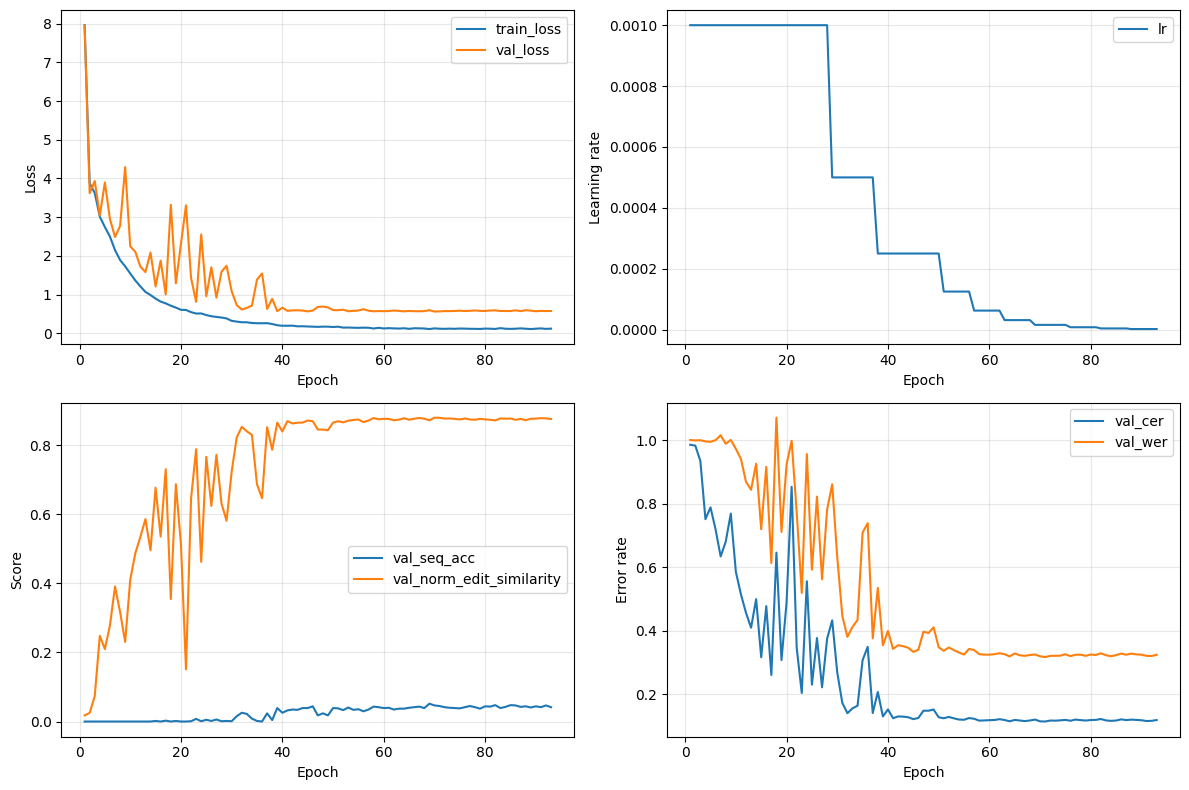

In [12]:
import torch
import matplotlib.pyplot as plt

ckpt = torch.load("checkpoints/last_model.pth", map_location="cpu")
history = ckpt["history"]

epochs = history["epoch"]
train_loss = history["train_loss"]
val_loss = history["val_loss"]
lr = history["lr"]
val_seq_acc = history.get("val_seq_acc", [])
val_cer = history.get("val_cer", [])
val_wer = history.get("val_wer", [])
val_norm_edit_similarity = history.get("val_norm_edit_similarity", [])

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.plot(epochs, train_loss, label="train_loss")
plt.plot(epochs, val_loss, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2,2,2)
plt.plot(epochs, lr, label="lr")
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.legend()
plt.grid(True, alpha=0.3)

if val_seq_acc:
    plt.subplot(2,2,3)
    plt.plot(epochs, val_seq_acc, label="val_seq_acc")
    plt.plot(epochs, val_norm_edit_similarity, label="val_norm_edit_similarity")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(2,2,4)
    plt.plot(epochs, val_cer, label="val_cer")
    plt.plot(epochs, val_wer, label="val_wer")
    plt.xlabel("Epoch")
    plt.ylabel("Error rate")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import torch
from pathlib import Path
from torch.utils.data import DataLoader

# ==================== TEST / INFERENCE ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
base_dir = Path.cwd()
checkpoint_dir = base_dir / "checkpoints"

best_model_path = checkpoint_dir / "best_model.pth"
last_model_path = checkpoint_dir / "last_model.pth"

if best_model_path.exists():
    checkpoint_path = best_model_path
elif last_model_path.exists():
    checkpoint_path = last_model_path
else:
    raise FileNotFoundError(
        f"No checkpoint found. Expected one of: {best_model_path} or {last_model_path}"
    )

ckpt = torch.load(str(checkpoint_path), map_location=device)

if isinstance(ckpt, dict) and "char_to_idx" in ckpt:
    char_to_idx = ckpt["char_to_idx"]
else:
    raise KeyError(
        "Checkpoint does not contain 'char_to_idx'. Re-train or save vocabulary in checkpoint."
    )

idx_to_char = {idx: char for char, idx in char_to_idx.items()}
num_classes = len(char_to_idx)

model = CNNBiLSTMCTC(num_classes=num_classes, input_height=100).to(device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    model.load_state_dict(ckpt["model_state_dict"])
else:
    # Backward compatibility: checkpoint might be a raw state_dict
    model.load_state_dict(ckpt)

model.eval()
print(f"Loaded checkpoint: {checkpoint_path}")

data_root = base_dir / "data_daxuli"
test_csv = data_root / "test_labels.csv"

if not test_csv.exists():
    raise FileNotFoundError(f"Missing test CSV: {test_csv}")

test_image_paths, test_labels = load_labels_csv(test_csv)
if not test_image_paths:
    raise RuntimeError("No valid test samples loaded from CSV.")

test_dataset = HandwritingDataset(
    image_paths=test_image_paths,
    labels=test_labels,
    char_to_idx=char_to_idx
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=(device.type == "cuda"),
    collate_fn=collate_fn
)

all_pred_texts = []
all_target_texts = []

with torch.no_grad():
    for images, labels, label_lengths in test_loader:
        images = images.to(device, non_blocking=True)
        log_probs = model(images)
        pred_texts = greedy_decode(log_probs, idx_to_char)
        target_texts = targets_to_strings(labels, label_lengths, idx_to_char)

        all_pred_texts.extend(pred_texts)
        all_target_texts.extend(target_texts)

metrics = compute_ocr_metrics(all_pred_texts, all_target_texts)
print(f"Test samples: {len(all_target_texts):,}")
print(f"Sequence Accuracy: {metrics['seq_acc']:.2%}")
print(f"CER: {metrics['cer']:.2%}")
print(f"WER: {metrics['wer']:.2%}")
print(f"Normalized Edit Similarity: {metrics['norm_edit_similarity']:.2%}")

print("\nSample predictions:")
for i, (pred, target) in enumerate(zip(all_pred_texts[:5], all_target_texts[:5]), start=1):
    print(f"{i:02d}. PRED: {pred}")
    print(f"    GT  : {target}")

NameError: name 'ckpt' is not defined